# M4bar ANN Model 2 Demo

### Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
rc('mathtext', fontset='cm')
from typing import Tuple, Dict, List
from IPython.display import display, Latex
from sklearn.metrics import explained_variance_score, max_error, mean_absolute_error,  mean_squared_error, r2_score, mean_absolute_percentage_error


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchmetrics, mlxtend

import torchinfo
from torchinfo import summary

import os
import re
import time


#### Set the device: cuda or cpu

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.set_device(device)

#### Get the data and create some useful features as extensions

#### Min and max values of stellar parameters

In [3]:
C_min = 0.0876; C_max = 0.3075;
x_min = 0.2472; x_max = 0.7818;
Qbar_min = 1.3134; Qbar_max = 14.2177;
logQbar_min = 0.2726; logQbar_max =2.6545 ;
S3bar_min = 1.7364; S3bar_max = 31.0343;
M4bar_min = 2.6546657; M4bar_max = 497.19217912;
M4bar_S3bar_min = 1.52452574; M4bar_S3bar_max = 16.02075562;


### min-max scaling

In [4]:
min_values = np.array([x_min, C_min, Qbar_min, S3bar_min]) 
max_values = np.array([x_max, C_max, Qbar_max, S3bar_max]) 

# min-max scaling function
feature_scaler = lambda data: (data - min_values) / (max_values - min_values)

#### Input layer features: model's input parameters

In [5]:
selected_features = ['x', 'C','Qbar','S3bar']

#### Test subample of NS configurations 

In [6]:
df_test = pd.read_csv("NS_data/test_data_M4bar_small_sample.csv")

In [7]:
df_test

,C,x,Qbar,log(Qbar),S3bar,M4bar,M4bar/S3bar,EoS
0,0.239153,0.428760,2.245936,0.809123,3.826176,10.698486,2.796130,KDE0v1
1,0.219189,0.613082,2.410448,0.879813,4.278630,12.784681,2.988031,GM1Y6
2,0.119218,0.600355,7.844361,2.059795,16.635909,149.459716,8.984163,DNS
3,0.227783,0.520024,2.358494,0.858023,4.093605,11.890598,2.904676,SLY2
4,0.152180,0.410496,5.973800,1.787383,12.238878,86.049167,7.030805,DS(CMF)-6
...,...,...,...,...,...,...,...,...
404,0.177359,0.580727,3.546486,1.265957,6.834829,29.341403,4.292925,SLY4
405,0.194989,0.519243,3.123775,1.139042,5.852527,22.408290,3.828823,KDE0v
406,0.148098,0.650069,4.285796,1.455306,8.775727,46.095249,5.252584,SK255
407,0.165745,0.282188,5.593451,1.721596,11.334649,75.747830,6.682856,DS(CMF)-2


In [8]:
def load_stars(data_frame, batch_size = 2048, shuffle = False): 
    
    
    df_target = (data_frame['M4bar']) 
    np_features = data_frame[selected_features].to_numpy()    
    
    np_targets = df_target.to_numpy()
    np_targets = np.reshape(np_targets, (np_targets.shape[0], 1))
    
    tensor_features = torch.Tensor(feature_scaler(np_features)) 
    
    input_dimension = tensor_features.shape[1]
    
    tensor_targets = torch.Tensor(np_targets)
    final_dataset = TensorDataset(tensor_features, tensor_targets)

    dataloader = DataLoader(final_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=5, pin_memory=True)

    return dataloader, input_dimension, np_features, np_targets

#### Dataloader

In [9]:
batch_size = 512
test_dataloader, input_dimension, _, _ = load_stars(df_test, batch_size = batch_size)

#### Feed-forward ANN Model to perform regression

In [10]:
class ModifiedSigmoid(nn.Module):
    def forward(self, x):
        return M4bar_min + (M4bar_max - M4bar_min)*torch.sigmoid(x) 

In [11]:
class RegressorModel(nn.Module):
    def __init__(self,input_dimension, feature_scaler):
        super().__init__()
        
        self.feature_scaler = feature_scaler
        
        self.MLP = nn.Sequential(
            
            nn.Linear(input_dimension, 120),
            nn.GELU(),
            nn.Linear(120, 75),  
            nn.GELU(),
            nn.Linear(75, 50), 
            nn.GELU(),
            nn.Linear(50, 25),  
            nn.GELU(),
            nn.Linear(25, 10),  
            nn.GELU(),
            nn.Linear(10, 1),  
            ModifiedSigmoid(), # a modification of sigmoid activation function 

        )
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.01)

    def forward(self, x):
        x = self.MLP(x)
        return x
    
    def predict(self, x):
        x = self.feature_scaler(x).astype('float32')
        x = torch.from_numpy(x).to(self.device)
        x = self.MLP(x)
        x = x.cpu().detach().numpy()
        return x
        
    def set_device(self, device):
        self.device = device    


In [12]:
model_0 = RegressorModel(input_dimension = input_dimension, feature_scaler = feature_scaler)
model_0

RegressorModel(
  (MLP): Sequential(
    (0): Linear(in_features=4, out_features=120, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=120, out_features=75, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=75, out_features=50, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=50, out_features=25, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=25, out_features=10, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=10, out_features=1, bias=True)
    (11): ModifiedSigmoid()
  )
)

In [13]:
summary(model_0)

Layer (type:depth-idx)                   Param #
RegressorModel                           --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       600
│    └─GELU: 2-2                         --
│    └─Linear: 2-3                       9,075
│    └─GELU: 2-4                         --
│    └─Linear: 2-5                       3,800
│    └─GELU: 2-6                         --
│    └─Linear: 2-7                       1,275
│    └─GELU: 2-8                         --
│    └─Linear: 2-9                       260
│    └─GELU: 2-10                        --
│    └─Linear: 2-11                      11
│    └─ModifiedSigmoid: 2-12             --
Total params: 15,021
Trainable params: 15,021
Non-trainable params: 0

### ANN Model evaluation 

#### Load the trained Model best weights $\theta^\star$

In [14]:
batch_size = 512
model_path = './Model-Weights/M4bar_inference/model_2.pth'
dataloader_test, _, np_features_test, np_targets_test = load_stars(df_test, batch_size=batch_size)

In [15]:
regressor = RegressorModel(input_dimension = input_dimension, feature_scaler = feature_scaler).to(device)
regressor.set_device(device)
regressor.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
regressor.eval()

RegressorModel(
  (MLP): Sequential(
    (0): Linear(in_features=4, out_features=120, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=120, out_features=75, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=75, out_features=50, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=50, out_features=25, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=25, out_features=10, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=10, out_features=1, bias=True)
    (11): ModifiedSigmoid()
  )
)

#### Residual Error - Fractional difference - Evaluation Measures

In [16]:
def plot_residuals(residual_error, percentage_error):
    witdh, height = 16, 6
    fontsize = 20
    labelsize = 15
    lw = 5
    
    fig, ax = plt.subplots(1, 2, figsize=(witdh, height))
    # Residual error subplot 
    ax[0].plot(residual_error, lw=lw)
    ax[0].set_xlabel(r'Datapoints', fontsize=fontsize)
    ax[0].set_ylabel(r'Residual', fontsize=fontsize)
    ax[0].tick_params(axis='both', which='both', labelsize=labelsize)

    # Percentage error subplot 
    ax[1].plot(percentage_error, lw=lw)
    ax[1].set_xlabel(r'Datapoints', fontsize=fontsize)
    ax[1].set_ylabel(r'$PE \ [\%]$', fontsize=fontsize)
    ax[1].tick_params(axis='both', which='both', labelsize=labelsize)

    plt.tight_layout()
    plt.show()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    fontsize = 20
    labelsize = 15
    lw = 5

    # Residual error histogram
    ax[0].hist(residual_error, bins = 20)
    ax[0].set_ylabel(r'Datapoints', fontsize=fontsize)
    ax[0].set_xlabel(r'Residual', fontsize=fontsize)
    ax[0].tick_params(axis='both', which='both', labelsize=labelsize)

    # Percentage error histogram
    ax[1].hist(percentage_error, bins = 20)
    ax[1].set_ylabel(r'Datapoints', fontsize=fontsize)
    ax[1].set_xlabel(r'$PE \ [\%]$', fontsize=fontsize)
    ax[1].tick_params(axis='both', which='both', labelsize=labelsize)

    plt.tight_layout()
    plt.show()

In [17]:
def Evaluation_Measures(y_true, y_pred):    

    exp_var = explained_variance_score(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    measures = {'explained_variance': [exp_var], 
                'max_error': [max_err],
                'mean_absolute_error': [mae],
                'mean_squared_error': [mse],
                'r2_score': [r2],
                'mean_absolute_percentage_error': [mape]}
   
    df_eval_measures = pd.DataFrame(measures)
    
    return df_eval_measures

#### Evaluation measures in Test Set subsample

In [18]:
np_targets_test = np_targets_test.ravel()

model_estimation_test_set = regressor.predict(np_features_test)
model_estimation_test_set = model_estimation_test_set.ravel().astype(np.float64) 

In [19]:
test_eval_measures = Evaluation_Measures(y_true = np_targets_test, y_pred = model_estimation_test_set)
test_eval_measures

,explained_variance,max_error,mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error
0,0.999981,3.617845,0.079723,0.064594,0.999981,0.0023


#### Redidual Errors and Pecentange Errors in the test Set subsample

In [20]:
residual_error_test = model_estimation_test_set - np_targets_test
percentage_error_test = (residual_error_test / np_targets_test) * 100

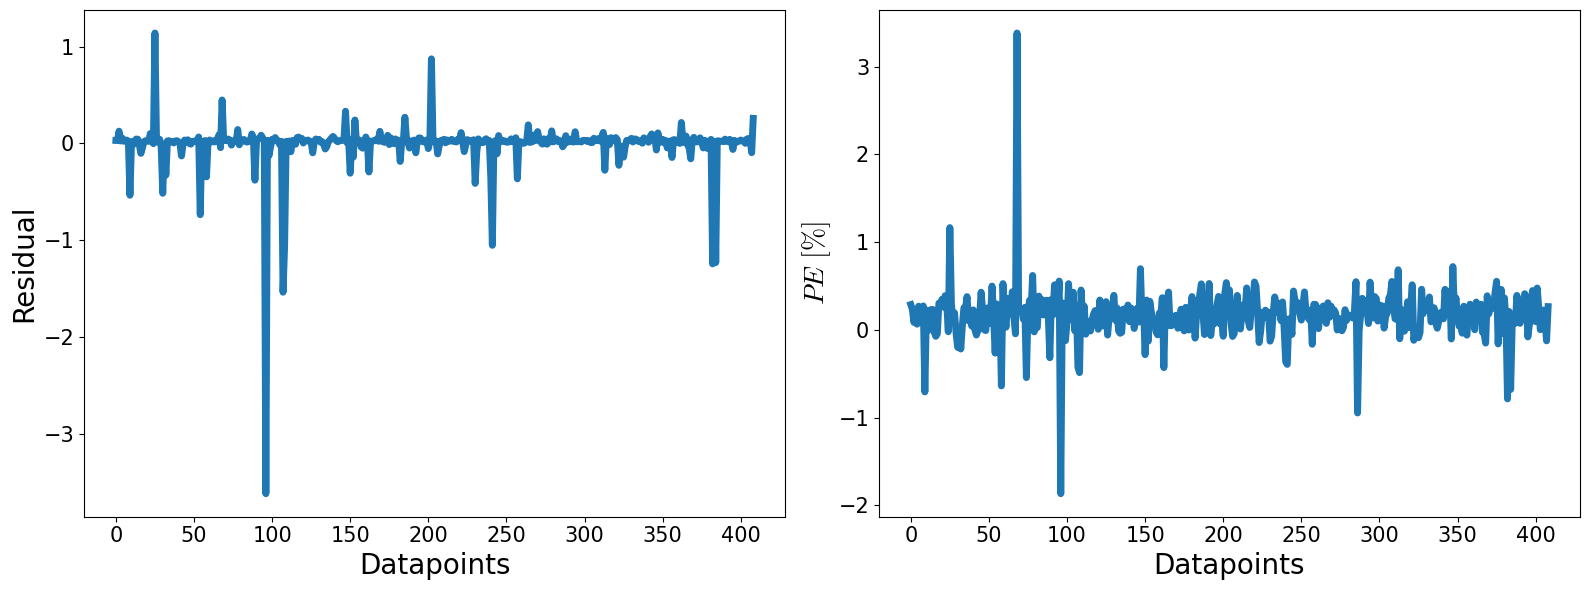

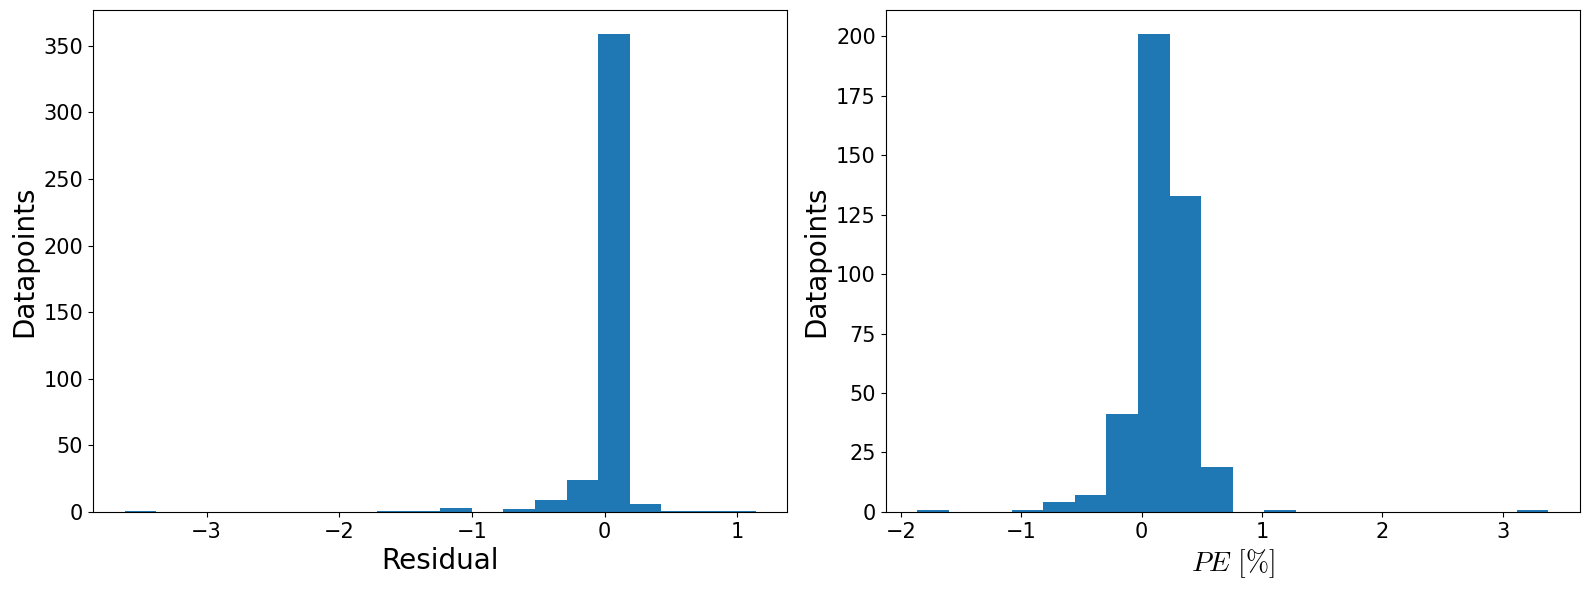

In [21]:
plot_residuals(residual_error_test, percentage_error_test)

In [22]:
df_test['M4bar_model'] = model_estimation_test_set

In [23]:
def M4bar_ANN_model(x,y,w,q):
    input_features = np.column_stack((x, y, w,q))
    ANN_estimation = regressor.predict(input_features)
    ANN_estimation = ANN_estimation.ravel().astype(np.float64) 
    return ANN_estimation.reshape(x.shape)

In [24]:
M4bar_ANN_model(df_test['x'], df_test['C'], df_test['Qbar'], df_test['S3bar'])

array([ 10.72916412,  12.81449127, 149.5859375 ,  11.91582298,
        86.10432434,   8.33922291,  26.7307148 ,  14.21144199,
         6.52410221,  75.0847702 ,   8.59298325, 185.97325134,
        12.05280781,  19.53627205,  18.71447563,  56.92594528,
       137.58625793, 101.36083221,   6.20589447,  10.10636044,
         6.96388817,   8.17412567,  26.26904297,  27.81379318,
         9.84574032,  99.08068848,   5.34893703,  52.57100677,
        21.75137329,  87.51617432, 256.65698242,  63.16297913,
       148.86503601,  55.00551224,  11.29631996,   7.17312336,
         5.63700867,   4.87739277,  12.53672028,  66.22763824,
         7.79163074,  62.37234879, 216.25585938, 108.11994934,
        26.86585236,   4.0793767 ,  16.86587143,  77.61589813,
        81.98164368,   8.96195793,  29.14053917,  21.84784698,
         5.8945713 ,  46.61069489, 276.17871094,   7.30485249,
        40.71283722,  11.62725735,  53.65083313,   4.09441996,
        28.71747208,  50.10175705,   6.71599007,   6.72

#### Model's fractional differences associated with the test set's subsample

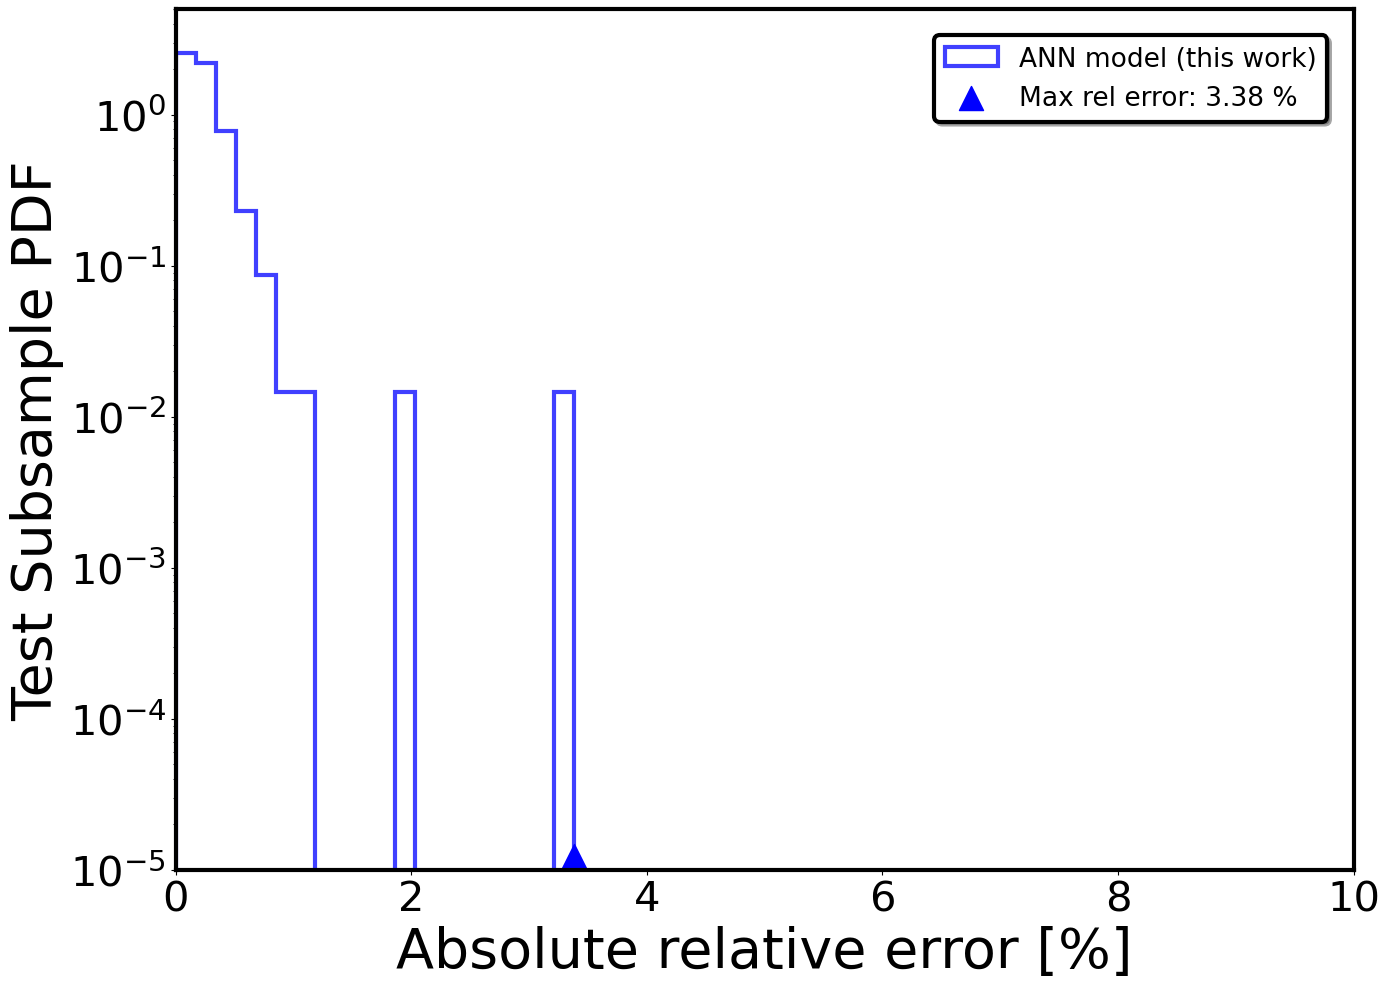

In [25]:
fig,ax = plt.subplots(figsize=(14, 10),)
labels_text_size = 40
plt.xticks(fontsize=30) #fontweight="bold"
plt.yticks(fontsize=30)

xlabel = r'Absolute relative error [%]'
ylabel = r'Test Subsample PDF'


plt.xlabel(xlabel,size=labels_text_size)
plt.ylabel(ylabel,size=labels_text_size)

bins = 20
alpha = 0.75

density = True

y_reg_model = (np.abs(100*(-df_test['M4bar'] + df_test['M4bar_model'])/df_test['M4bar'])).hist(
    density=density, 
    bins=bins, 
    lw=3, 
    edgecolor='blue', 
    zorder=1, 
    histtype='step', 
    alpha=alpha, 
    label=r"ANN model (this work)", 
    color='blue',
).autoscale(enable=True, axis='both', tight=True)

max_deviation = (np.abs(100*(-df_test['M4bar'] + df_test['M4bar_model'])/df_test['M4bar'])).max()

vertical_lines = [max_deviation]  


plt.scatter(vertical_lines[0], 1.23e-5, color='blue',  marker='^', s=300, zorder=2, label=f'Max rel error: {np.round(max_deviation, 2)} %')  # Star marker

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3.)


plt.yscale('log')

plt.xlim(0,10.)

plt.ylim(1e-5,5)

plt.grid(False)
leg = plt.legend(loc="upper right",ncol=1, borderaxespad=1, prop={'size': 19}, shadow=True, fontsize="large")    #,bbox_to_anchor=(1,1)
leg.get_frame().set_linewidth(3.0)
leg.get_frame().set_edgecolor('black')

plt.tight_layout()
plt.show()